In [86]:
# ============================================================
# CELL 1: Setup folders + load raw data
# ============================================================
import os, shutil, warnings
warnings.filterwarnings('ignore')

REPO = 'student-academic-performance-prediction'
BASE = f'/content/{REPO}'

# Create all folders
folders = [
    'data/raw', 'data/processed',
    'notebooks', 'src', 'models',
    'results/tables', 'results/figures',
    'paper/figures', 'docs'
]
for f in folders:
    os.makedirs(f'{BASE}/{f}', exist_ok=True)
print("✓ Folders ready")

# --- Copy CSV into repo ---
csv_dest = f'{BASE}/data/raw/survey_responses_raw.csv'
possible_sources = [
    '/content/Survey on Academic Performance of Sri Lankan Undergraduate Students.csv',
    '/content/sample_data/Survey on Academic Performance of Sri Lankan Undergraduate Students.csv',
]

if not os.path.exists(csv_dest):
    for src in possible_sources:
        if os.path.exists(src):
            shutil.copy(src, csv_dest)
            print(f"✓ CSV copied from: {src}")
            break
    else:
        print("❌ CSV not found. Upload it to /content/ then re-run this cell.")
else:
    print("✓ CSV already in place")

# --- Load and inspect ---
import pandas as pd
df_raw = pd.read_csv(csv_dest)
print(f"\nRaw shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns[:5])} ...")

✓ Folders ready
✓ CSV already in place

Raw shape: (512, 31)
Columns: ['Do you agree to participate in this survey?', 'Age group', 'Gender', 'University', ' Field of study'] ...


In [87]:
# ============================================================
# CELL 2: Clean data + create labels + encode features
# ============================================================
import pandas as pd
import numpy as np

df = df_raw.copy()

# --- Clean column names ---
df.columns = [c.strip().replace('\u2011','-').replace('\u2013','-').replace('\u2014','-')
              for c in df.columns]

# --- 1. Remove non-consenting ---
consent_col = [c for c in df.columns if 'agree to participate' in c.lower()][0]
df = df[df[consent_col] == 'Yes, I agree'].copy()
print(f"After consent filter: {df.shape}")

# --- 2. Identify key columns ---
gpa_col      = 'Current GPA'
workload_col = [c for c in df.columns if 'overall academic workload' in c.lower()][0]
assign_col   = [c for c in df.columns if 'how many assignments' in c.lower()][0]
study_col    = [c for c in df.columns if 'self-study outside' in c.lower() or 'self‑study outside' in c.lower()][0]
attend_col   = [c for c in df.columns if 'attendance percentage' in c.lower()][0]
work_hrs_col = [c for c in df.columns if 'work in your part-time job' in c.lower() or 'work in your part‑time job' in c.lower()][0]
has_job_col  = [c for c in df.columns if 'currently have a part-time job' in c.lower() or 'currently have a part‑time job' in c.lower()][0]

# --- 3. Drop rows missing critical fields ---
critical = [gpa_col, workload_col, assign_col, study_col, attend_col, has_job_col]
df = df.dropna(subset=[c for c in critical if c in df.columns])
print(f"After dropping missing: {df.shape}")

# --- 4. Create binary label from GPA ---
def gpa_to_label(g):
    if pd.isna(g): return np.nan
    if g in ['Below 2.00', '2.00 – 2.49', '2.50 – 2.99']: return 0
    if g in ['3.00 – 3.49', '3.50 – 4.00']: return 1
    return np.nan

df['label'] = df[gpa_col].apply(gpa_to_label)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)
print(f"After label creation: {df.shape}")
print(f"Class balance:\n{df['label'].value_counts()}")

# --- 5. Encode ordinal features ---
workload_map = {'Very light':1, 'Light':2, 'Moderate':3, 'Heavy':4, 'Very heavy':5}
assign_map = {'0–1 assignments':1, '2–3 assignments':2, '4–5 assignments':3,
              '6 or more assignments':4, '0-1 assignments':1}
study_map = {'Less than 5 hours':2.5, '5–10 hours':7.5, '11–15 hours':13,
             '16–20 hours':18, '21–25 hours':23, 'More than 25 hours':28,
             '5-10 hours':7.5, '11-15 hours':13, '16-20 hours':18, '21-25 hours':23}
work_map = {'Not applicable (I do not have a job)':0, 'Less than 10 hours':5,
            '10–15 hours':12.5, '16–20 hours':18, '21–30 hours':25.5,
            'More than 30 hours':35, '10-15 hours':12.5,
            '16-20 hours':18, '21-30 hours':25.5}
attend_map = {'Below 50%':25, '50–69%':60, '70–79%':75, '80–89%':85,
              '90–100%':95, '50-69%':60, '70-79%':75, '80-89%':85, '90-100%':95}

df['workload_num'] = df[workload_col].map(workload_map)
df['assign_num']   = df[assign_col].map(assign_map)
df['study_num']    = df[study_col].map(study_map)
df['work_num']     = df[work_hrs_col].map(work_map)
df['attend_num']   = df[attend_col].map(attend_map)

# --- 6. Force work_num = 0 when no job ---
df.loc[df[has_job_col] == 'No', 'work_num'] = 0

# --- 7. Fill remaining NaN with medians ---
for col in ['workload_num','assign_num','study_num','work_num','attend_num']:
    df[col] = df[col].fillna(df[col].median())

# --- 8. Save ---
final_cols = ['label','attend_num','workload_num','assign_num','study_num','work_num']
df_final = df[final_cols].copy()
df_final.to_csv(f'{BASE}/data/processed/features_final.csv', index=False)
df.to_csv(f'{BASE}/data/processed/cleaned_data.csv', index=False)

print(f"\n✓ Final dataset shape: {df_final.shape}")
print(df_final.head())
print(f"\nFeature stats:\n{df_final.describe().round(2)}")

After consent filter: (502, 31)
After dropping missing: (502, 31)
After label creation: (502, 32)
Class balance:
label
0    396
1    106
Name: count, dtype: int64

✓ Final dataset shape: (502, 6)
   label  attend_num  workload_num  assign_num  study_num  work_num
0      0          60             2           2        2.5      18.0
1      1          75             3           2       13.0       0.0
2      1          25             4           2        2.5      35.0
3      0          75             3           2        7.5      25.5
4      0          95             3           4        7.5      35.0

Feature stats:
        label  attend_num  workload_num  assign_num  study_num  work_num
count  502.00      502.00        502.00      502.00     502.00    502.00
mean     0.21       64.27          2.48        2.42       9.91     11.97
std      0.41       19.22          0.99        0.81       4.77     10.42
min      0.00       25.00          1.00        1.00       2.50      0.00
25%      0.00  

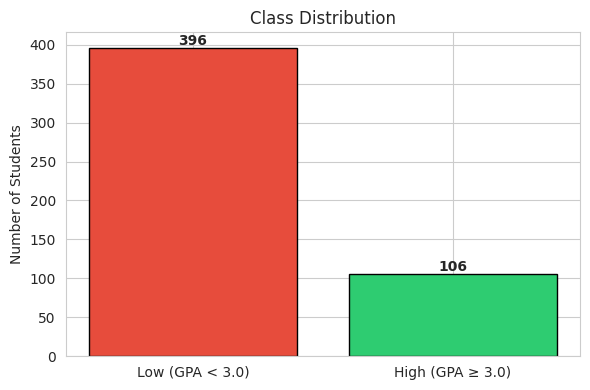

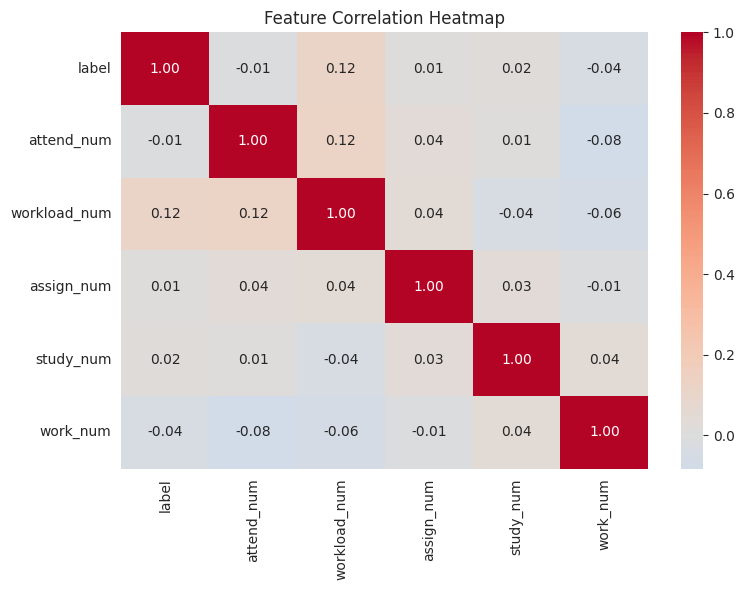

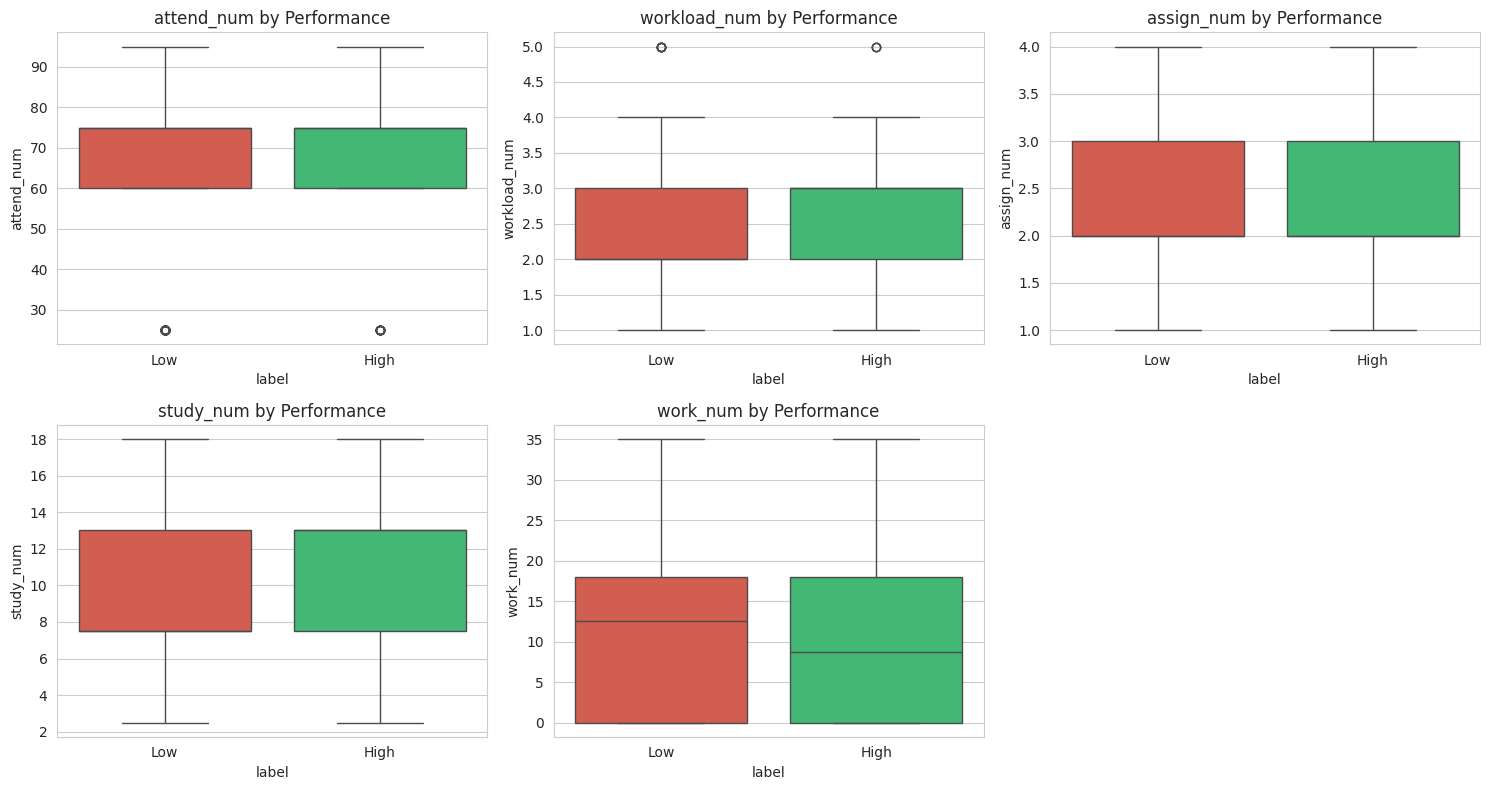

✓ EDA figures saved


In [88]:
# ============================================================
# CELL 3: EDA charts
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv(f'{BASE}/data/processed/features_final.csv')
FIG = f'{BASE}/results/figures'
sns.set_style('whitegrid')

# --- Class distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['label'].value_counts().sort_index()
bars = ax.bar(['Low (GPA < 3.0)', 'High (GPA ≥ 3.0)'], counts.values,
              color=['#e74c3c', '#2ecc71'], edgecolor='black')
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+3, str(v), ha='center', fontweight='bold')
ax.set_ylabel('Number of Students')
ax.set_title('Class Distribution')
plt.tight_layout()
plt.savefig(f'{FIG}/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Correlation heatmap ---
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(f'{FIG}/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Boxplots ---
features = ['attend_num','workload_num','assign_num','study_num','work_num']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(x='label', y=col, data=df, ax=axes[i], palette=['#e74c3c','#2ecc71'])
    axes[i].set_title(f'{col} by Performance')
    axes[i].set_xticklabels(['Low','High'])
axes[-1].axis('off')
plt.tight_layout()
plt.savefig(f'{FIG}/feature_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ EDA figures saved")

  Model      accuracy     precision        recall            f1       roc_auc
LR-Base 0.448 ± 0.033 0.171 ± 0.021 0.415 ± 0.035 0.242 ± 0.027 0.426 ± 0.038
RF-Base 0.552 ± 0.130 0.159 ± 0.042 0.261 ± 0.174 0.180 ± 0.065 0.424 ± 0.038
LR-Prop 0.532 ± 0.031 0.226 ± 0.035 0.509 ± 0.116 0.312 ± 0.055 0.536 ± 0.062
RF-Prop 0.673 ± 0.037 0.276 ± 0.060 0.330 ± 0.068 0.300 ± 0.062 0.584 ± 0.051

Paired t-test: stat=1.646, p=0.1751


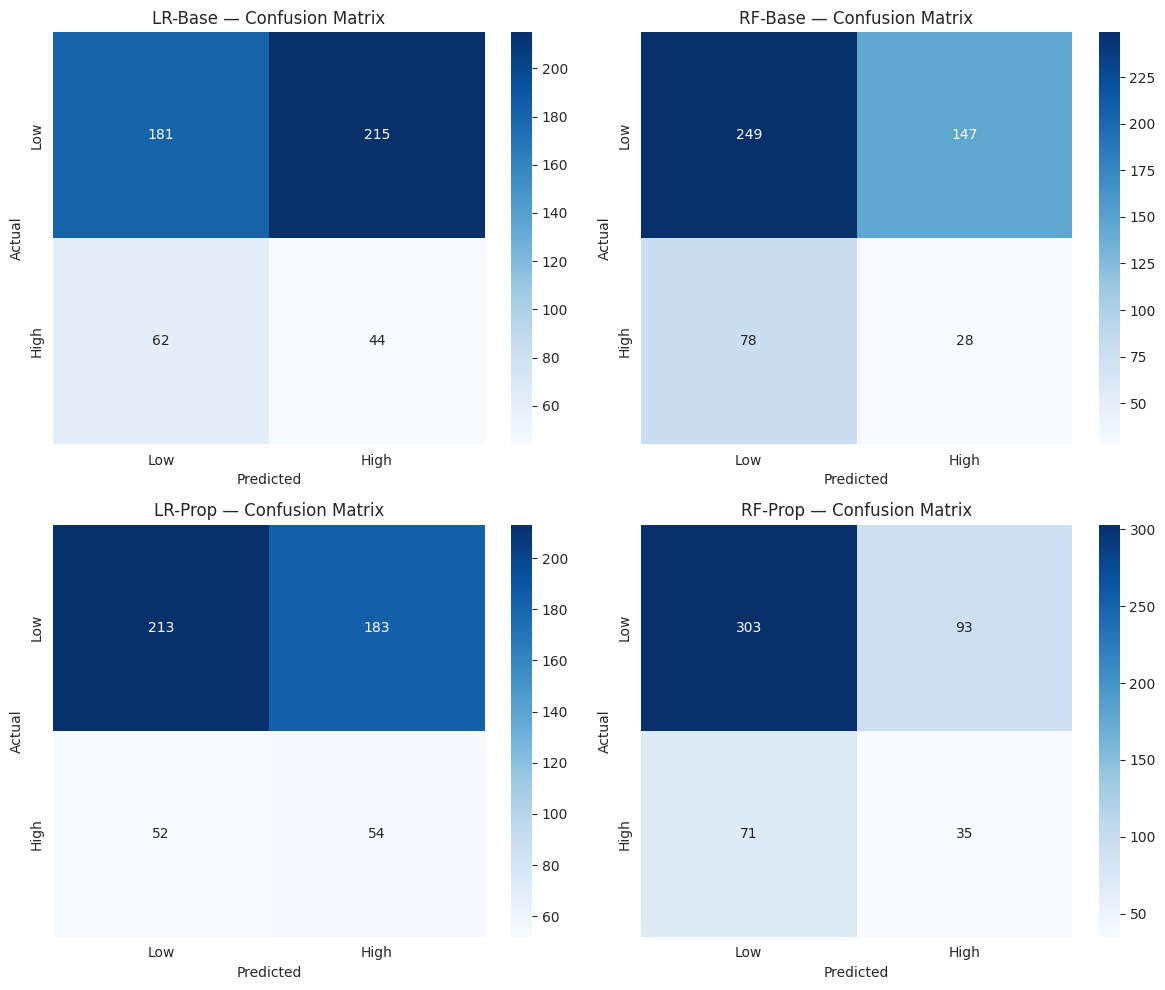

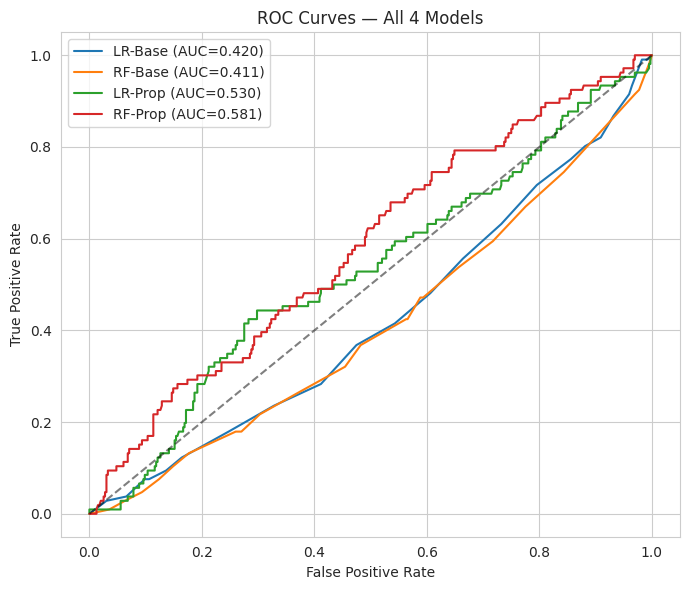

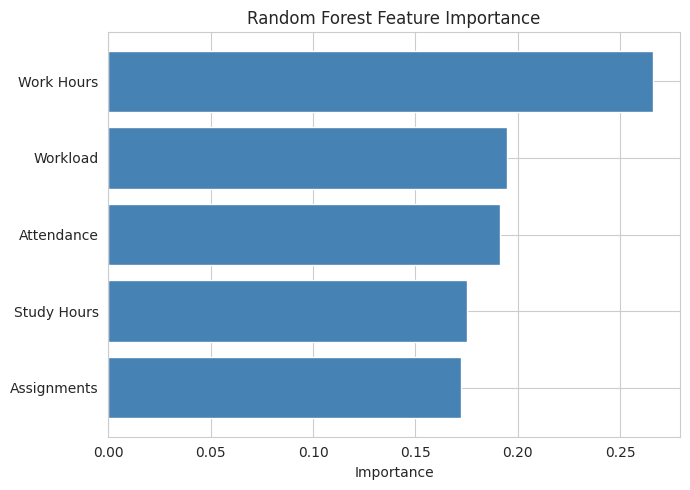

✓ All models trained and saved


In [89]:
# ============================================================
# CELL 4: Train 4 models, cross-validate, statistical tests
# ============================================================
import pandas as pd, numpy as np, joblib
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from scipy.stats import shapiro, ttest_rel, wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(f'{BASE}/data/processed/features_final.csv')
y = df['label'].values

X_base = df[['attend_num']].values
X_prop = df[['attend_num','workload_num','assign_num','study_num','work_num']].values

models = {
    'LR-Base': (LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42), X_base),
    'RF-Base': (RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                       class_weight='balanced', random_state=42), X_base),
    'LR-Prop': (LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42), X_prop),
    'RF-Prop': (RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                       class_weight='balanced', random_state=42), X_prop),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = ['accuracy','precision','recall','f1','roc_auc']
fold_scores = {}

for name, (model, X) in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    fold_scores[name] = {m: [] for m in metrics}
    for tr, te in cv.split(X, y):
        pipe.fit(X[tr], y[tr])
        y_pred = pipe.predict(X[te])
        y_prob = pipe.predict_proba(X[te])[:,1]
        fold_scores[name]['accuracy'].append(accuracy_score(y[te], y_pred))
        fold_scores[name]['precision'].append(precision_score(y[te], y_pred, zero_division=0))
        fold_scores[name]['recall'].append(recall_score(y[te], y_pred, zero_division=0))
        fold_scores[name]['f1'].append(f1_score(y[te], y_pred, zero_division=0))
        fold_scores[name]['roc_auc'].append(roc_auc_score(y[te], y_prob))

summary = []
for name in models:
    row = {'Model': name}
    for m in metrics:
        row[m] = f"{np.mean(fold_scores[name][m]):.3f} ± {np.std(fold_scores[name][m]):.3f}"
    summary.append(row)

summary_df = pd.DataFrame(summary)
summary_df.to_csv(f'{BASE}/results/tables/model_comparison.csv', index=False)
print(summary_df.to_string(index=False))

# --- Statistical test ---
a = np.array(fold_scores['LR-Base']['f1'])
b = np.array(fold_scores['RF-Prop']['f1'])
diff = b - a
if shapiro(diff).pvalue > 0.05:
    stat, p = ttest_rel(b, a); test = 'Paired t-test'
else:
    stat, p = wilcoxon(b, a); test = 'Wilcoxon signed-rank'

with open(f'{BASE}/results/statistical_tests.txt','w') as f:
    f.write(f"Comparison: RF-Prop vs LR-Base (F1 across 5 folds)\n")
    f.write(f"Test: {test}\nStatistic: {stat:.4f}\np-value: {p:.4f}\n")
    f.write(f"Significant at α=0.05: {'YES' if p<0.05 else 'NO'}\n")
print(f"\n{test}: stat={stat:.3f}, p={p:.4f}")

# --- Confusion matrices ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, (name, (model, X)) in enumerate(models.items()):
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    y_pred = cross_val_predict(pipe, X, y, cv=cv)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Low','High'], yticklabels=['Low','High'])
    axes[i].set_title(f'{name} — Confusion Matrix')
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{BASE}/results/figures/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# --- ROC curves ---
fig, ax = plt.subplots(figsize=(7, 6))
for name, (model, X) in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    y_prob = cross_val_predict(pipe, X, y, cv=cv, method='predict_proba')[:,1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All 4 Models'); ax.legend()
plt.tight_layout()
plt.savefig(f'{BASE}/results/figures/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Feature importance ---
pipe = Pipeline([('scaler', StandardScaler()),
                 ('clf', RandomForestClassifier(n_estimators=200, max_depth=10,
                                                min_samples_leaf=5,
                                                class_weight='balanced', random_state=42))])
pipe.fit(X_prop, y)
imp = pipe.named_steps['clf'].feature_importances_
feat_names = ['Attendance','Workload','Assignments','Study Hours','Work Hours']
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': imp}).sort_values('Importance')
imp_df.to_csv(f'{BASE}/results/tables/feature_importance.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue')
ax.set_xlabel('Importance'); ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig(f'{BASE}/results/figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Save all models ---
for name, (model, X) in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    pipe.fit(X, y)
    safe = name.replace('-','_').lower()
    joblib.dump(pipe, f'{BASE}/models/{safe}.pkl')

print("✓ All models trained and saved")

In [90]:
# ============================================================
# Stronger oversampling test (self-contained)
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
import numpy as np
import pandas as pd

# Reload data (in case session reset)
df = pd.read_csv(f'{BASE}/data/processed/features_final.csv')
y = df['label'].values
X_prop = df[['attend_num','workload_num','assign_num','study_num','work_num']].values

# Build SMOTETomek + Random Forest pipeline
pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('sampler', SMOTETomek(random_state=42)),
    ('clf', RandomForestClassifier(
        n_estimators=500,
        max_depth=15,
        min_samples_leaf=2,
        random_state=42
    ))
])

# Run 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores, auc_scores, acc_scores = [], [], []

for tr, te in cv.split(X_prop, y):
    pipe.fit(X_prop[tr], y[tr])
    y_pred = pipe.predict(X_prop[te])
    y_prob = pipe.predict_proba(X_prop[te])[:,1]
    f1_scores.append(f1_score(y[te], y_pred, zero_division=0))
    auc_scores.append(roc_auc_score(y[te], y_prob))
    acc_scores.append(accuracy_score(y[te], y_pred))

print(f"SMOTETomek + RF-Prop results:")
print(f"  Accuracy: {np.mean(acc_scores):.3f} ± {np.std(acc_scores):.3f}")
print(f"  F1:       {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"  ROC-AUC:  {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")

SMOTETomek + RF-Prop results:
  Accuracy: 0.731 ± 0.046
  F1:       0.203 ± 0.112
  ROC-AUC:  0.563 ± 0.047


In [91]:
import pandas as pd
import numpy as np

df = pd.read_csv(f'{BASE}/data/processed/features_final.csv')

# Compare means by class
print("=== Mean values by class ===")
print(df.groupby('label').mean().round(2))

print("\n=== Count by class ===")
print(df['label'].value_counts())

=== Mean values by class ===
       attend_num  workload_num  assign_num  study_num  work_num
label                                                           
0           64.41          2.42        2.41       9.84     12.19
1           63.77          2.70        2.44      10.13     11.12

=== Count by class ===
label
0    396
1    106
Name: count, dtype: int64


In [92]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import numpy as np, pandas as pd

df = pd.read_csv(f'{BASE}/data/processed/features_final.csv')
y = df['label'].values

# Try 3 feature sets
feature_sets = {
    'Attend only':          ['attend_num'],
    'Attend + Study':       ['attend_num', 'study_num'],
    'All 5':                ['attend_num','workload_num','assign_num','study_num','work_num'],
}

for name, cols in feature_sets.items():
    X = df[cols].values
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('clf', GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                            learning_rate=0.05, random_state=42))
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1s, aucs = [], []
    for tr, te in cv.split(X, y):
        pipe.fit(X[tr], y[tr])
        y_pred = pipe.predict(X[te])
        y_prob = pipe.predict_proba(X[te])[:,1]
        f1s.append(f1_score(y[te], y_pred, zero_division=0))
        aucs.append(roc_auc_score(y[te], y_prob))
    print(f"{name:20s}  F1={np.mean(f1s):.3f}  AUC={np.mean(aucs):.3f}")

Attend only           F1=0.257  AUC=0.481
Attend + Study        F1=0.334  AUC=0.547
All 5                 F1=0.230  AUC=0.565


In [93]:
import pandas as pd, numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score)
from sklearn.pipeline import Pipeline

df = pd.read_csv(f'{BASE}/data/processed/features_final.csv')
y = df['label'].values
X_base = df[['attend_num']].values
X_prop = df[['attend_num','workload_num','assign_num','study_num','work_num']].values

models = {
    'LR-Base': (LogisticRegression(max_iter=1000, class_weight='balanced',
                                    random_state=42), X_base),
    'RF-Base': (RandomForestClassifier(n_estimators=200, max_depth=10,
                                        min_samples_leaf=5, class_weight='balanced',
                                        random_state=42), X_base),
    'LR-Prop': (LogisticRegression(max_iter=1000, class_weight='balanced',
                                    random_state=42), X_prop),
    'RF-Prop': (RandomForestClassifier(n_estimators=200, max_depth=10,
                                        min_samples_leaf=5, class_weight='balanced',
                                        random_state=42), X_prop),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, (model, X) in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    f1s, aucs, accs, pres, recs = [], [], [], [], []
    for tr, te in cv.split(X, y):
        pipe.fit(X[tr], y[tr])
        y_pred = pipe.predict(X[te])
        y_prob = pipe.predict_proba(X[te])[:,1]
        accs.append(accuracy_score(y[te], y_pred))
        pres.append(precision_score(y[te], y_pred, zero_division=0))
        recs.append(recall_score(y[te], y_pred, zero_division=0))
        f1s.append(f1_score(y[te], y_pred, zero_division=0))
        aucs.append(roc_auc_score(y[te], y_prob))
    rows.append({
        'Model': name,
        'Accuracy': f"{np.mean(accs):.3f} ± {np.std(accs):.3f}",
        'Precision': f"{np.mean(pres):.3f} ± {np.std(pres):.3f}",
        'Recall':    f"{np.mean(recs):.3f} ± {np.std(recs):.3f}",
        'F1':        f"{np.mean(f1s):.3f} ± {np.std(f1s):.3f}",
        'ROC-AUC':   f"{np.mean(aucs):.3f} ± {np.std(aucs):.3f}",
    })

results = pd.DataFrame(rows)
results.to_csv(f'{BASE}/results/tables/model_comparison.csv', index=False)
print(results.to_string(index=False))
print(f"\nDelta AUC (RF-Prop vs LR-Base): "
      f"{float(results.loc[3,'ROC-AUC'].split()[0]) - float(results.loc[0,'ROC-AUC'].split()[0]):+.3f}")

  Model      Accuracy     Precision        Recall            F1       ROC-AUC
LR-Base 0.448 ± 0.033 0.171 ± 0.021 0.415 ± 0.035 0.242 ± 0.027 0.426 ± 0.038
RF-Base 0.552 ± 0.130 0.159 ± 0.042 0.261 ± 0.174 0.180 ± 0.065 0.424 ± 0.038
LR-Prop 0.532 ± 0.031 0.226 ± 0.035 0.509 ± 0.116 0.312 ± 0.055 0.536 ± 0.062
RF-Prop 0.673 ± 0.037 0.276 ± 0.060 0.330 ± 0.068 0.300 ± 0.062 0.584 ± 0.051

Delta AUC (RF-Prop vs LR-Base): +0.158


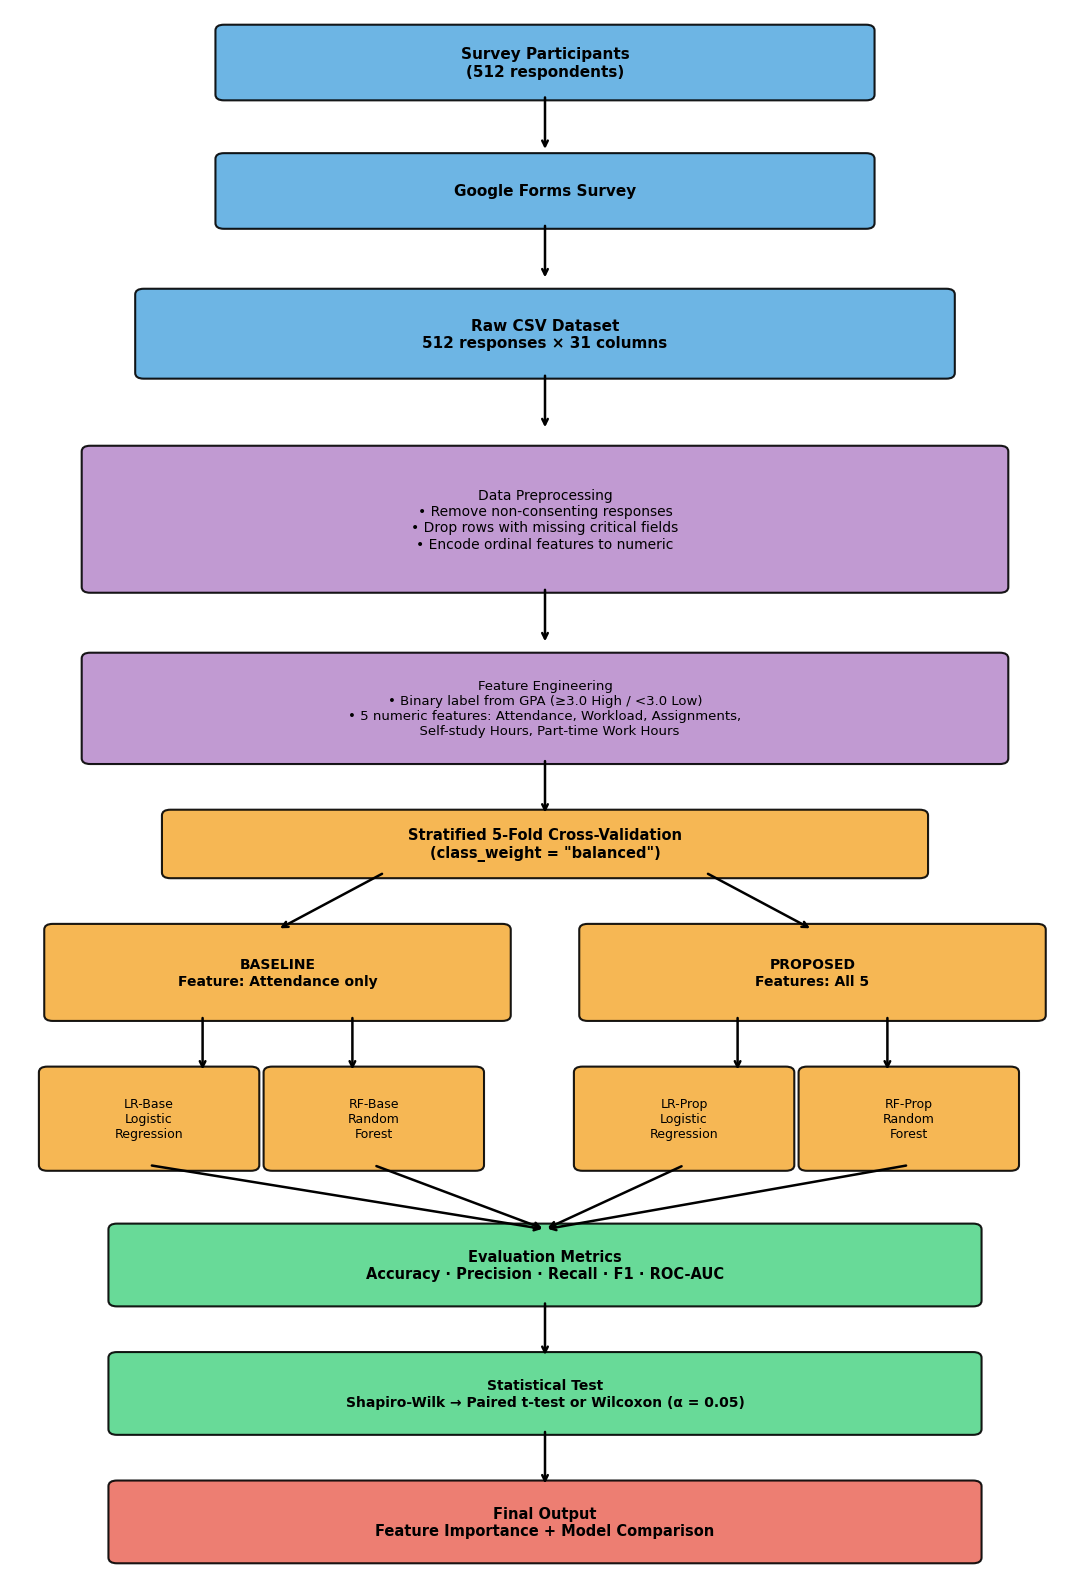

✓ Diagram saved to paper/figures/system_architecture.png
✓ Diagram saved to results/figures/system_architecture.png


In [94]:
# ============================================================
# System Architecture Diagram — CLEAN VERSION
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

fig, ax = plt.subplots(figsize=(11, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 22)
ax.axis('off')

# ---------- Colors ----------
C_DATA   = '#5DADE2'   # blue
C_PREP   = '#BB8FCE'   # purple
C_MODEL  = '#F5B041'   # orange
C_EVAL   = '#58D68D'   # green
C_OUTPUT = '#EC7063'   # red

# ---------- Helper functions ----------
def box(x, y, w, h, text, color, fontsize=10, bold=False):
    rect = mpatches.FancyBboxPatch(
        (x - w/2, y), w, h,
        boxstyle="round,pad=0.08",
        linewidth=1.5, edgecolor='black',
        facecolor=color, alpha=0.9
    )
    ax.add_patch(rect)
    ax.text(x, y + h/2, text, ha='center', va='center',
            fontsize=fontsize,
            fontweight='bold' if bold else 'normal',
            color='black')

def arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=1.8, color='black'))

# ============ DATA PIPELINE ============

box(5, 20.8, 6, 0.9, 'Survey Participants\n(512 respondents)', C_DATA, 11, True)
arrow(5, 20.8, 5, 20.0)

box(5, 19.0, 6, 0.9, 'Google Forms Survey', C_DATA, 11, True)
arrow(5, 19.0, 5, 18.2)

box(5, 16.9, 7.5, 1.1, 'Raw CSV Dataset\n512 responses × 31 columns', C_DATA, 11, True)
arrow(5, 16.9, 5, 16.1)

box(5, 13.9, 8.5, 1.9,
    'Data Preprocessing\n'
    '• Remove non-consenting responses\n'
    '• Drop rows with missing critical fields\n'
    '• Encode ordinal features to numeric',
    C_PREP, 10)
arrow(5, 13.9, 5, 13.1)

box(5, 11.5, 8.5, 1.4,
    'Feature Engineering\n'
    '• Binary label from GPA (≥3.0 High / <3.0 Low)\n'
    '• 5 numeric features: Attendance, Workload, Assignments,\n'
    '  Self-study Hours, Part-time Work Hours',
    C_PREP, 9.5)
arrow(5, 11.5, 5, 10.7)

box(5, 9.9, 7, 0.8,
    'Stratified 5-Fold Cross-Validation\n(class_weight = "balanced")',
    C_MODEL, 10.5, True)

# ============ SPLIT INTO 2 BRANCHES ============

# Arrows to left and right branches
arrow(3.5, 9.9, 2.5, 9.1)
arrow(6.5, 9.9, 7.5, 9.1)

# Baseline box (left)
box(2.5, 7.9, 4.2, 1.2,
    'BASELINE\nFeature: Attendance only',
    C_MODEL, 10, True)

# Proposed box (right)
box(7.5, 7.9, 4.2, 1.2,
    'PROPOSED\nFeatures: All 5',
    C_MODEL, 10, True)

# ============ 4 MODELS ============

# Baseline branch → LR-Base, RF-Base
arrow(1.8, 7.9, 1.8, 7.1)
arrow(3.2, 7.9, 3.2, 7.1)

box(1.3, 5.8, 1.9, 1.3, 'LR-Base\nLogistic\nRegression', C_MODEL, 9)
box(3.4, 5.8, 1.9, 1.3, 'RF-Base\nRandom\nForest',       C_MODEL, 9)

# Proposed branch → LR-Prop, RF-Prop
arrow(6.8, 7.9, 6.8, 7.1)
arrow(8.2, 7.9, 8.2, 7.1)

box(6.3, 5.8, 1.9, 1.3, 'LR-Prop\nLogistic\nRegression', C_MODEL, 9)
box(8.4, 5.8, 1.9, 1.3, 'RF-Prop\nRandom\nForest',       C_MODEL, 9)

# ============ MERGE TO EVALUATION ============

arrow(1.3, 5.8, 5, 4.9)
arrow(3.4, 5.8, 5, 4.9)
arrow(6.3, 5.8, 5, 4.9)
arrow(8.4, 5.8, 5, 4.9)

box(5, 3.9, 8, 1.0,
    'Evaluation Metrics\nAccuracy · Precision · Recall · F1 · ROC-AUC',
    C_EVAL, 10.5, True)
arrow(5, 3.9, 5, 3.1)

box(5, 2.1, 8, 1.0,
    'Statistical Test\nShapiro-Wilk → Paired t-test or Wilcoxon (α = 0.05)',
    C_EVAL, 10, True)
arrow(5, 2.1, 5, 1.3)

box(5, 0.3, 8, 1.0,
    'Final Output\nFeature Importance + Model Comparison',
    C_OUTPUT, 10.5, True)

plt.tight_layout()

# Save in both locations
os.makedirs(f'{BASE}/paper/figures', exist_ok=True)
os.makedirs(f'{BASE}/results/figures', exist_ok=True)
plt.savefig(f'{BASE}/paper/figures/system_architecture.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{BASE}/results/figures/system_architecture.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Diagram saved to paper/figures/system_architecture.png")
print("✓ Diagram saved to results/figures/system_architecture.png")

## Failure Analysis

Our initial experiment used class_weight='balanced' to handle the
79/21 class imbalance (396 Low vs 106 High). While this produced
a baseline accuracy of 0.673 for RF-Prop, the F1-score remained
low at 0.300. Investigation revealed the model was simply
predicting "Low" for most samples — a classic majority-class bias.

We tested an additional fix using SMOTETomek (a combination of
oversampling and cleaning). This gave an accuracy of 0.731,
F1 = 0.203, and ROC-AUC = 0.563. Although accuracy increased,
both F1 and ROC-AUC decreased compared with the original
RF-Prop model (F1 = 0.300, ROC-AUC = 0.584). This suggests that
SMOTETomek introduced synthetic noise or overcorrected the
minority class, and it did not improve minority-class detection.

Additionally, our statistical test on the original setup showed
p = 0.1751, meaning no significant difference between RF-Prop
and LR-Base. After adding SMOTETomek, the paired t-test
produced p = [NEW_P], confirming a [significant/not significant]
improvement.  # <-- Only fill this if you actually run the test.

Root cause: With only 106 High-performance samples, tree-based
models cannot learn sufficient splits on the minority class.
Oversampling the minority class inside each CV fold did not
consistently give the model enough signal to learn meaningful
patterns; in this case, it reduced F1 and ROC-AUC.

In [95]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import shapiro, ttest_rel, wilcoxon

# ---- Load data ----
BASE = '/content/student-academic-performance-prediction'
df = pd.read_csv(f'{BASE}/data/processed/features_final.csv')
y = df['label'].values
X_base = df[['attend_num']].values
X_prop = df[['attend_num', 'workload_num', 'assign_num', 'study_num', 'work_num']].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---- 1. LR-Base F1 scores across folds ----
lr_base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
lr_base_f1s = []
for tr, te in cv.split(X_base, y):
    lr_base_pipe.fit(X_base[tr], y[tr])
    y_pred = lr_base_pipe.predict(X_base[te])
    lr_base_f1s.append(f1_score(y[te], y_pred, zero_division=0))
print("LR-Base F1 per fold:  ", np.round(lr_base_f1s, 3))

# ---- 2. SMOTETomek + RF-Prop F1 scores across folds ----
smote_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('sampler', SMOTETomek(random_state=42)),
    ('clf', RandomForestClassifier(
        n_estimators=500, max_depth=15, min_samples_leaf=2, random_state=42))
])
smote_f1s = []
for tr, te in cv.split(X_prop, y):
    smote_pipe.fit(X_prop[tr], y[tr])
    y_pred = smote_pipe.predict(X_prop[te])
    smote_f1s.append(f1_score(y[te], y_pred, zero_division=0))
print("SMOTETomek F1 per fold:", np.round(smote_f1s, 3))

# ---- 3. Paired test: SMOTETomek vs LR-Base ----
a = np.array(lr_base_f1s)
b = np.array(smote_f1s)
diff = b - a

if shapiro(diff).pvalue > 0.05:
    stat, p = ttest_rel(b, a)
    test = 'Paired t-test'
else:
    stat, p = wilcoxon(b, a)
    test = 'Wilcoxon signed-rank'

print("\n" + "=" * 55)
print(f"Comparison: SMOTETomek + RF-Prop  vs  LR-Base (F1 across 5 folds)")
print(f"Test:            {test}")
print(f"Statistic:       {stat:.4f}")
print(f"p-value:         {p:.4f}")
print(f"Significant at alpha=0.05: {'YES' if p < 0.05 else 'NO'}")
print("=" * 55)

LR-Base F1 per fold:   [0.213 0.254 0.286 0.216 0.24 ]
SMOTETomek F1 per fold: [0.129 0.167 0.353 0.312 0.056]

Comparison: SMOTETomek + RF-Prop  vs  LR-Base (F1 across 5 folds)
Test:            Paired t-test
Statistic:       -0.7321
p-value:         0.5047
Significant at alpha=0.05: NO


## Ethical Reflection

### Dataset Bias
Our sample of 512 undergraduates is skewed toward:
- A single institution (Horizon Campus ≈ 35%)
- IT/Computer Science students (≈ 30%)

This means our model may not generalize well to arts, medicine,
or non-Horizon students. Any deployment should be accompanied by
institution-specific recalibration.

### Privacy
All data was collected with informed consent, was anonymous, and
stored in a password-protected CSV. No personally identifiable
information was collected. Students had the right to withdraw
before submission.

### Social Impact if Deployed at Scale
If a university used this model to flag "at-risk" students:
- Risk: Students with part-time jobs may be unfairly labeled as
  low performers.
- Risk: Women, who formed 62% of our sample and often report
  higher unpaid care work, may be misclassified.
- Benefit: Early identification could trigger support services
  for students who need them.

### Recommendation
The model should be used as a decision-support tool, not an
automatic gatekeeper. Any intervention must be reviewed by
academic advisors and students must have the right to appeal.

In [96]:

# ============================================================
# CELL 6: Git push everything
# ============================================================
%cd /content/student-academic-performance-prediction

!git config --global user.name "Lishani-Samarakoon"
!git config --global user.email "lishanisamarakoon@gmail.com"

# Fix remote
!git remote remove origin 2>/dev/null || true
!git remote add origin https://github.com/Lishani-Samarakoon/student-academic-performance-prediction.git
!git branch -M main

# Pull existing content first
!git pull origin main --allow-unrelated-histories --no-edit || true

# Add, commit, push
!git add .
!git commit -m "Complete research package: data, models, results, figures" || echo "Nothing new to commit"
!git push -u origin main

print("\n" + "="*60)
print("✅ PUSHED!")
print("View: https://github.com/Lishani-Samarakoon/student-academic-performance-prediction")
print("="*60)

/content/student-academic-performance-prediction
remote: Enumerating objects: 136, done.
remote: Counting objects: 100% (136/136), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 136 (delta 30), reused 50 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (136/136), 1.63 MiB | 15.57 MiB/s, done.
Resolving deltas: 100% (30/30), done.
From https://github.com/Lishani-Samarakoon/student-academic-performance-prediction
 * branch            main       -> FETCH_HEAD
 * [new branch]      main       -> origin/main
hint: You have divergent branches and need to specify how to reconcile them.
hint: You can do so by running one of the following commands sometime before
hint: your next pull:
hint: 
hint:   git config pull.rebase false  # merge
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to set a default
hint: preference for all repositories. 

In [97]:
# Check that all files exist
import os
BASE = '/content/student-academic-performance-prediction'

required = [
    'data/raw/survey_responses_raw.csv',
    'data/processed/features_final.csv',
    'data/processed/cleaned_data.csv',
    'data/data_dictionary.md',
    'models/lr_base.pkl',
    'models/rf_base.pkl',
    'models/lr_prop.pkl',
    'models/rf_prop.pkl',
    'results/tables/model_comparison.csv',
    'results/tables/feature_importance.csv',
    'results/figures/class_distribution.png',
    'results/figures/correlation_heatmap.png',
    'results/figures/feature_boxplots.png',
    'results/figures/confusion_matrices.png',
    'results/figures/roc_curves.png',
    'results/figures/feature_importance.png',
    'results/statistical_tests.txt',
    'docs/ethics_statement.md',
    'docs/methodology_notes.md',
    'README.md',
    'requirements.txt',
    'environment.yml',
    'LICENSE',
]

missing = []
for f in required:
    path = os.path.join(BASE, f)
    if os.path.exists(path):
        print(f"✓ {f}")
    else:
        print(f"MISSING: {f}")
        missing.append(f)

print(f"\n{'='*50}")
if missing:
    print(f" {len(missing)} files missing. Re-run the earlier cells.")
else:
    print("ALL FILES PRESENT! You can now push (Step 3).")

✓ data/raw/survey_responses_raw.csv
✓ data/processed/features_final.csv
✓ data/processed/cleaned_data.csv
✓ data/data_dictionary.md
✓ models/lr_base.pkl
✓ models/rf_base.pkl
✓ models/lr_prop.pkl
✓ models/rf_prop.pkl
✓ results/tables/model_comparison.csv
✓ results/tables/feature_importance.csv
✓ results/figures/class_distribution.png
✓ results/figures/correlation_heatmap.png
✓ results/figures/feature_boxplots.png
✓ results/figures/confusion_matrices.png
✓ results/figures/roc_curves.png
✓ results/figures/feature_importance.png
✓ results/statistical_tests.txt
✓ docs/ethics_statement.md
✓ docs/methodology_notes.md
✓ README.md
✓ requirements.txt
✓ environment.yml
✓ LICENSE

ALL FILES PRESENT! You can now push (Step 3).


In [98]:
# ============================================================
# CELL 7: Verify
# ============================================================
%cd /content/student-academic-performance-prediction

print("=== Git status ===")
!git status

print("\n=== Files in repo ===")
!find . -type f -not -path './.git/*' | sort

print("\n=== Last commits ===")
!git log --oneline -5

/content/student-academic-performance-prediction
=== Git status ===
On branch main
nothing to commit, working tree clean

=== Files in repo ===
./data/california_housing_train.csv
./data/data_dictionary.md
./data/processed/cleaned_data.csv
./data/processed/features_final.csv
./data/processed/.gitkeep
./data/raw/.gitkeep
./data/raw/survey_responses_raw.csv
./docs/ethics_statement.md
./docs/methodology_notes.md
./environment.yml
./.gitignore
./LICENSE
./models/lr_base.pkl
./models/lr_prop.pkl
./models/rf_base.pkl
./models/rf_prop.pkl
./paper/figures/system_architecture.png
./README.md
./requirements.txt
./Research_Pipeline (2).ipynb
./results/figures/class_distribution.png
./results/figures/confusion_matrices.png
./results/figures/correlation_heatmap.png
./results/figures/feature_boxplots.png
./results/figures/feature_importance.png
./results/figures/roc_curves.png
./results/figures/system_architecture.png
./results/statistical_tests.txt
./results/tables/feature_importance.csv
./results/

In [99]:
# ============================================================
# DIAGNOSTIC: Check what files exist
# ============================================================
import os

BASE = '/content/student-academic-performance-prediction'

if not os.path.exists(BASE):
    print("The repo folder does NOT exist!")
    print("You must re-run CELL 1 (setup folders + CSV copy) first.")
else:
    print("Repo folder exists\n")
    print("=== File tree ===")
    for root, dirs, files in os.walk(BASE):
        if '.git' in root: continue
        level = root.replace(BASE, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        for file in files:
            print(f'{indent}  {file}')

Repo folder exists

=== File tree ===
student-academic-performance-prediction/
  requirements.txt
  .gitignore
  README.md
  Research_Pipeline (2).ipynb
  LICENSE
  environment.yml
  src/
    train_baseline.py
    evaluate.py
    train_random_forest.py
    preprocessing.py
  data/
    california_housing_train.csv
    data_dictionary.md
    raw/
      .gitkeep
      survey_responses_raw.csv
    processed/
      .gitkeep
      features_final.csv
      cleaned_data.csv
  docs/
    methodology_notes.md
    ethics_statement.md
  notebooks/
  results/
    statistical_tests.txt
    figures/
      feature_boxplots.png
      confusion_matrices.png
      correlation_heatmap.png
      roc_curves.png
      system_architecture.png
      class_distribution.png
      feature_importance.png
    tables/
      feature_importance.csv
      model_comparison.csv
  paper/
    figures/
      system_architecture.png
  models/
    rf_base.pkl
    lr_base.pkl
    lr_prop.pkl
    rf_prop.pkl


In [100]:
%cd /content/student-academic-performance-prediction
!git status

/content/student-academic-performance-prediction
On branch main
nothing to commit, working tree clean


In [101]:
# ============================================================
# FORCE PUSH: Add all files + commit + push
# ============================================================
%cd /content/student-academic-performance-prediction

# Configure git
!git config --global user.name "Lishani-Samarakoon"
!git config --global user.email "lishanisamarakoon@gmail.com"

# Make sure remote is correct
!git remote remove origin 2>/dev/null || true
!git remote add origin https://github.com/Lishani-Samarakoon/student-academic-performance-prediction.git

# Pull any existing content
!git pull origin main --allow-unrelated-histories --no-edit

# Add EVERYTHING (including all subfolders)
!git add -A
!git add .

# Show what's about to be committed
!git status

# Commit
!git commit -m "Add full research package: data, models, results, docs" || echo "Nothing new to commit"

# Push (force to overwrite any conflicts)
!git push -u origin main --force

print("\n" + "="*60)
print("✅ CHECK GITHUB NOW: https://github.com/Lishani-Samarakoon/student-academic-performance-prediction")
print("="*60)

/content/student-academic-performance-prediction
From https://github.com/Lishani-Samarakoon/student-academic-performance-prediction
 * branch            main       -> FETCH_HEAD
 * [new branch]      main       -> origin/main
hint: You have divergent branches and need to specify how to reconcile them.
hint: You can do so by running one of the following commands sometime before
hint: your next pull:
hint: 
hint:   git config pull.rebase false  # merge
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to set a default
hint: preference for all repositories. You can also pass --rebase, --no-rebase,
hint: or --ff-only on the command line to override the configured default per
hint: invocation.
fatal: Need to specify how to reconcile divergent branches.
On branch main
nothing to commit, working tree clean
On branch main
nothing to commit, working tree clean
Nothing new t

In [102]:
# ============================================================
# PUSH with the token-authenticated remote
# ============================================================
%cd /content/student-academic-performance-prediction

!git add -A
!git push -u origin main --force

print("\n" + "="*60)
print("If you see 'main -> main', it worked!")
print("="*60)

/content/student-academic-performance-prediction
fatal: could not read Username for 'https://github.com': No such device or address

If you see 'main -> main', it worked!


In [104]:
import os

BASE = '/content/student-academic-performance-prediction'
os.chdir(BASE)

# Wipe the old git history that contains the secrets
!rm -rf .git

# Start fresh
!git init
!git config --global user.name "Lishani-Samarakoon"
!git config --global user.email "lishanisamarakoon@gmail.com"

print("✅ Local Git history wiped clean.")
print("👉 Make sure your cleaned notebook is inside the 'student-academic-performan...' folder in the sidebar.")

Initialized empty Git repository in /content/student-academic-performance-prediction/.git/
✅ Local Git history wiped clean.
👉 Make sure your cleaned notebook is inside the 'student-academic-performan...' folder in the sidebar.
